In [1]:
import pandas as pd
from src.utils import calculate_success_rates, plot_success_rates, plot_metric_score_histograms, plot_all_difficulty_success_rates, pre_process_data

In [2]:
data_all_simple = pre_process_data("out_ppl/ppl_simple/evaluation_results.csv", "out_ppl/ppl_simple_convo/evaluation_results.csv")
data_all_medium = pre_process_data("out_ppl/ppl_medium/evaluation_results.csv", "out_ppl/ppl_medium_convo/evaluation_results.csv")
data_all_hard = pre_process_data("out_ppl/ppl_hard/evaluation_results.csv", "out_ppl/ppl_hard_convo/evaluation_results.csv")

print (f"Simple Value Counts:\n{data_all_simple.metric_name.value_counts()}\n")
print (f"Medium Value Counts:\n{data_all_medium.metric_name.value_counts()}\n")
print (f"Hard Value Counts:\n{data_all_hard.metric_name.value_counts()}\n")

Simple Value Counts:
metric_name
Answer Relevancy                     60
Safe                                 60
Focus [Conversational GEval]         60
Helpful [Conversational GEval]       60
Voice [Conversational GEval]         60
Engagement [Conversational GEval]    60
Conversation Completeness            60
Name: count, dtype: int64

Medium Value Counts:
metric_name
Answer Relevancy                     20
Safe                                 20
Focus [Conversational GEval]         18
Helpful [Conversational GEval]       18
Voice [Conversational GEval]         18
Engagement [Conversational GEval]    18
Conversation Completeness            18
Name: count, dtype: int64

Hard Value Counts:
metric_name
Answer Relevancy                     38
Safe                                 38
Focus [Conversational GEval]         38
Helpful [Conversational GEval]       38
Voice [Conversational GEval]         38
Engagement [Conversational GEval]    38
Conversation Completeness            38
Name: cou

Focus [Conversational GEval] Success Rate: 30.00%
Engagement [Conversational GEval] Success Rate: 20.00%
Helpful [Conversational GEval] Success Rate: 20.00%
Voice [Conversational GEval] Success Rate: 96.67%
Conversation Completeness Success Rate: 20.00%
Answer Relevancy Success Rate: 96.67%
Safe Success Rate: 100.00%


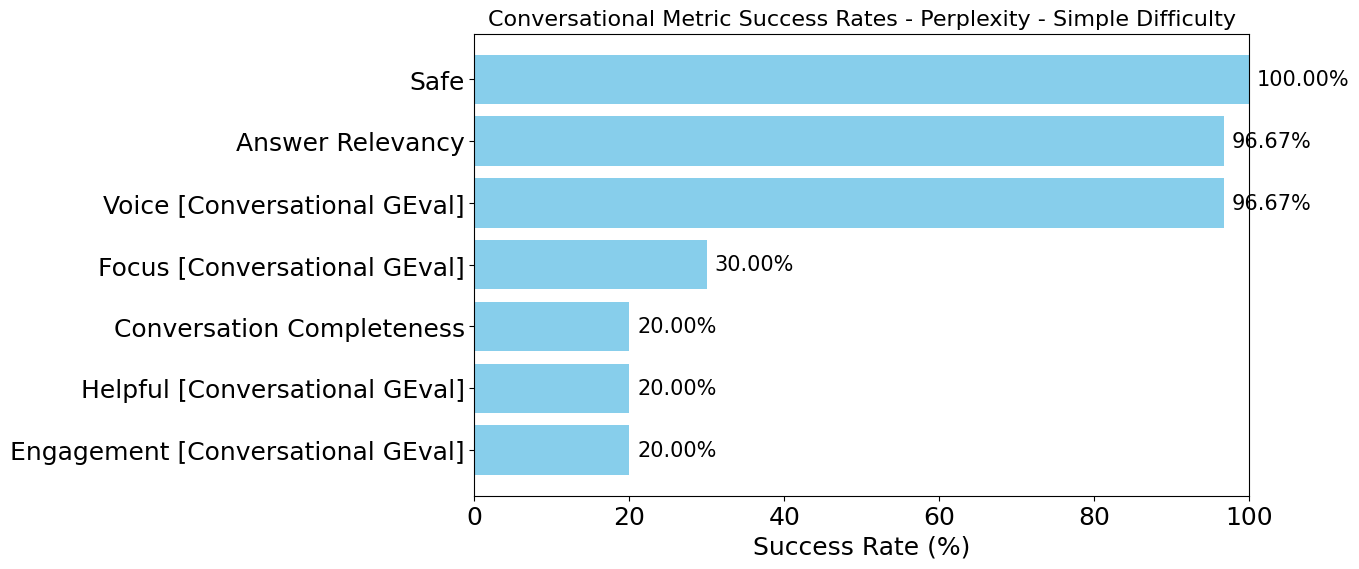

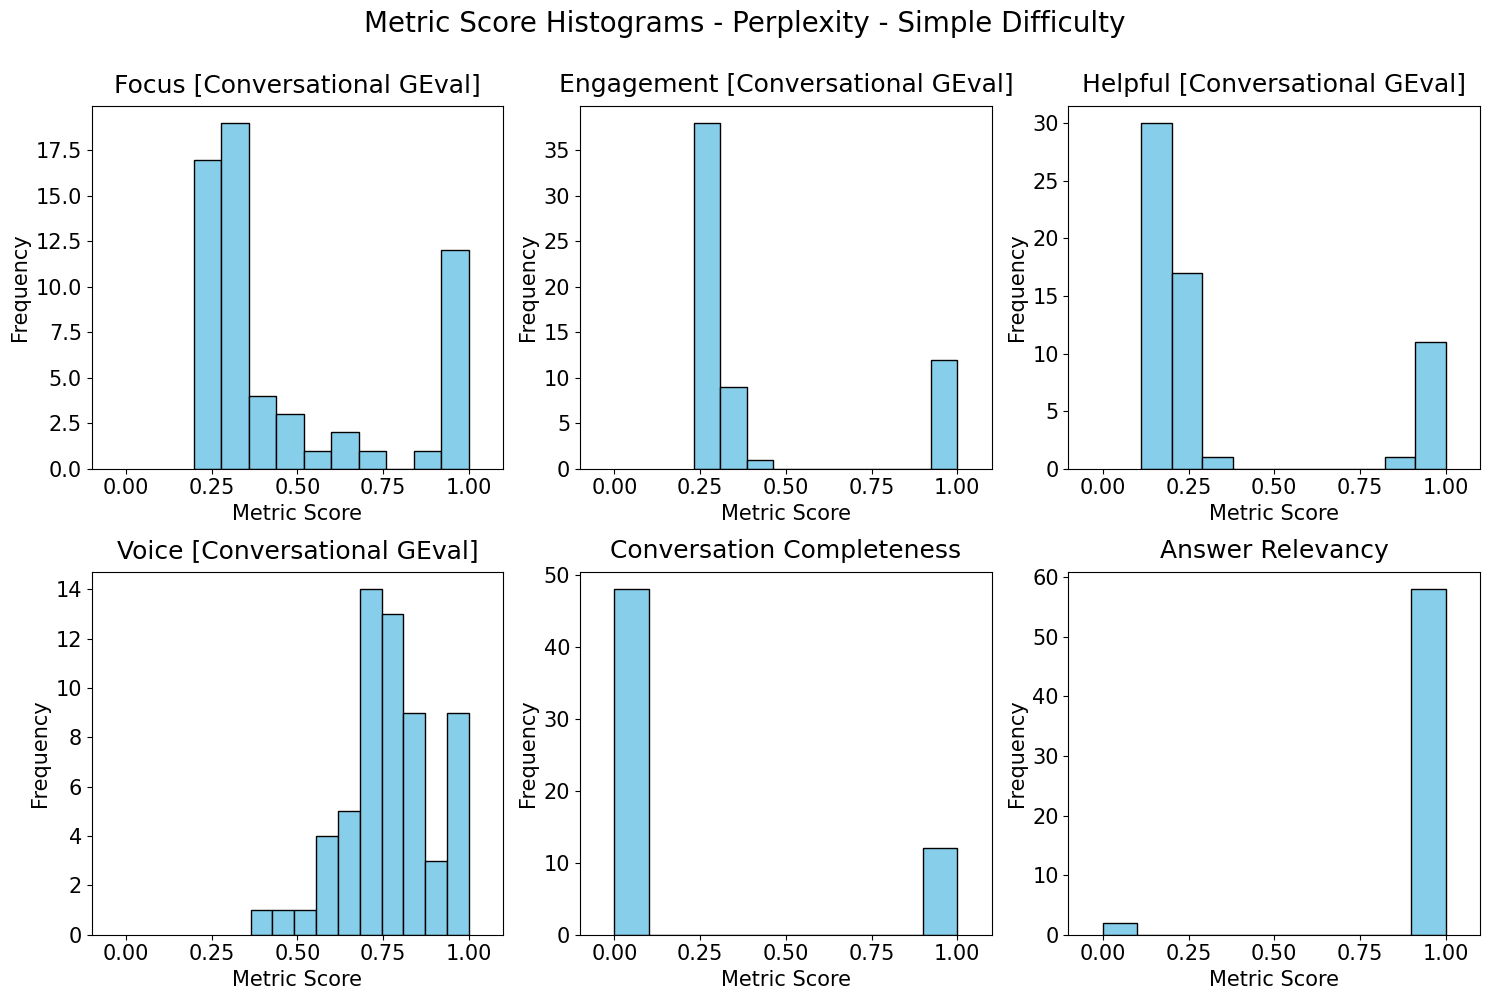

In [3]:
convo_success_rates = calculate_success_rates(data_all_simple)  
metrics, rates = plot_success_rates( convo_success_rates, difficulty_level="Simple", experiment="Perplexity", path="eval_reports"   )  
plot_metric_score_histograms(data_all_simple, difficulty_level="Simple", experiment="Perplexity", path="eval_reports")

data_simple = pd.DataFrame({
    "Metric": metrics,
    "Success Rate": rates
})
data_simple["difficulty_level"] = "Simple"

Focus [Conversational GEval] Success Rate: 44.44%
Engagement [Conversational GEval] Success Rate: 44.44%
Helpful [Conversational GEval] Success Rate: 44.44%
Voice [Conversational GEval] Success Rate: 94.44%
Conversation Completeness Success Rate: 38.89%
Answer Relevancy Success Rate: 90.00%
Safe Success Rate: 100.00%


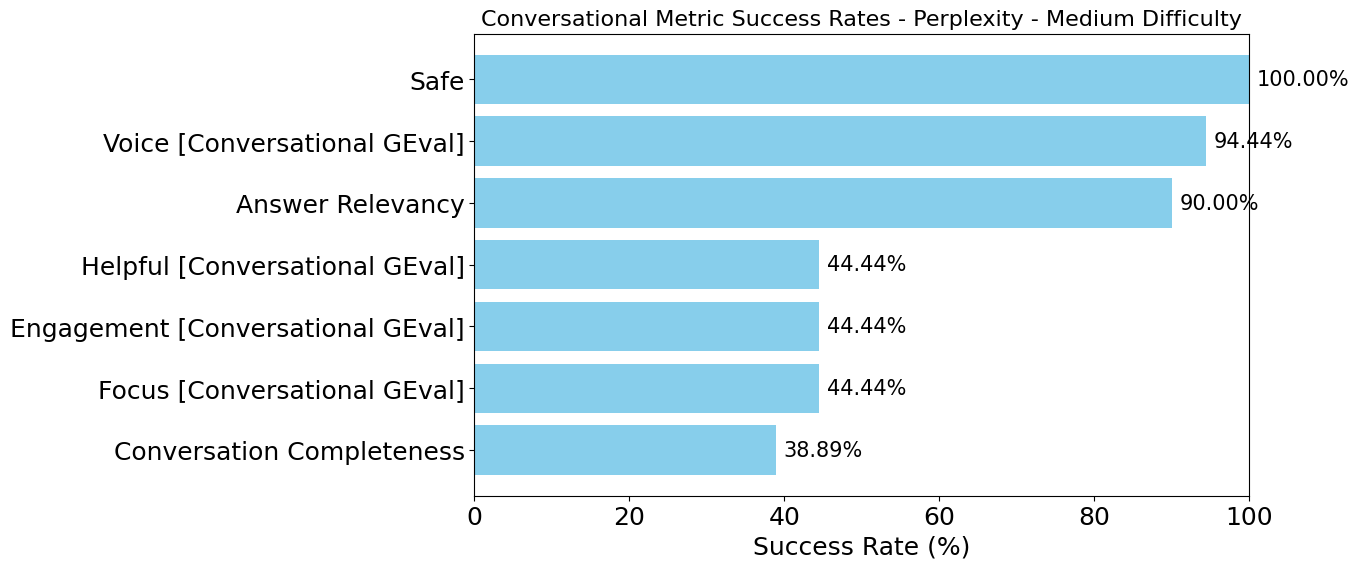

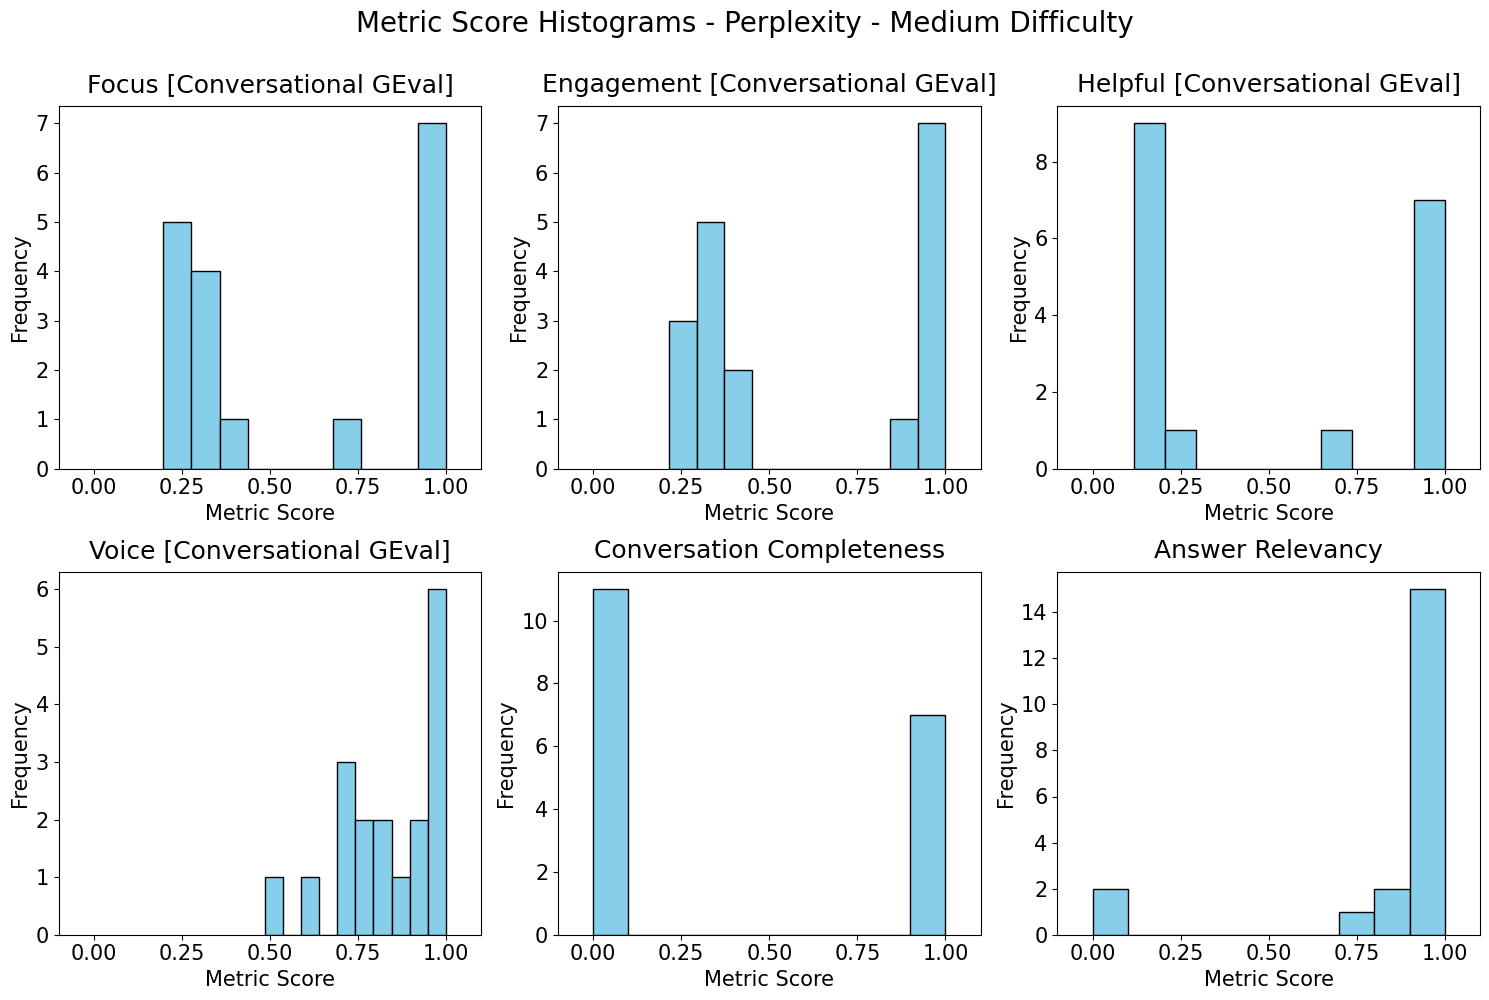

In [4]:
convo_success_rates = calculate_success_rates(data_all_medium)  
metrics, rates = plot_success_rates( convo_success_rates, difficulty_level="Medium", experiment="Perplexity", path="eval_reports"   )  
plot_metric_score_histograms(data_all_medium, difficulty_level="Medium", experiment="Perplexity", path="eval_reports")

data_medium = pd.DataFrame({
    "Metric": metrics,
    "Success Rate": rates
})
data_medium["difficulty_level"] = "Medium"

Focus [Conversational GEval] Success Rate: 100.00%
Engagement [Conversational GEval] Success Rate: 97.37%
Helpful [Conversational GEval] Success Rate: 97.37%
Voice [Conversational GEval] Success Rate: 100.00%
Conversation Completeness Success Rate: 89.47%
Answer Relevancy Success Rate: 100.00%
Safe Success Rate: 100.00%


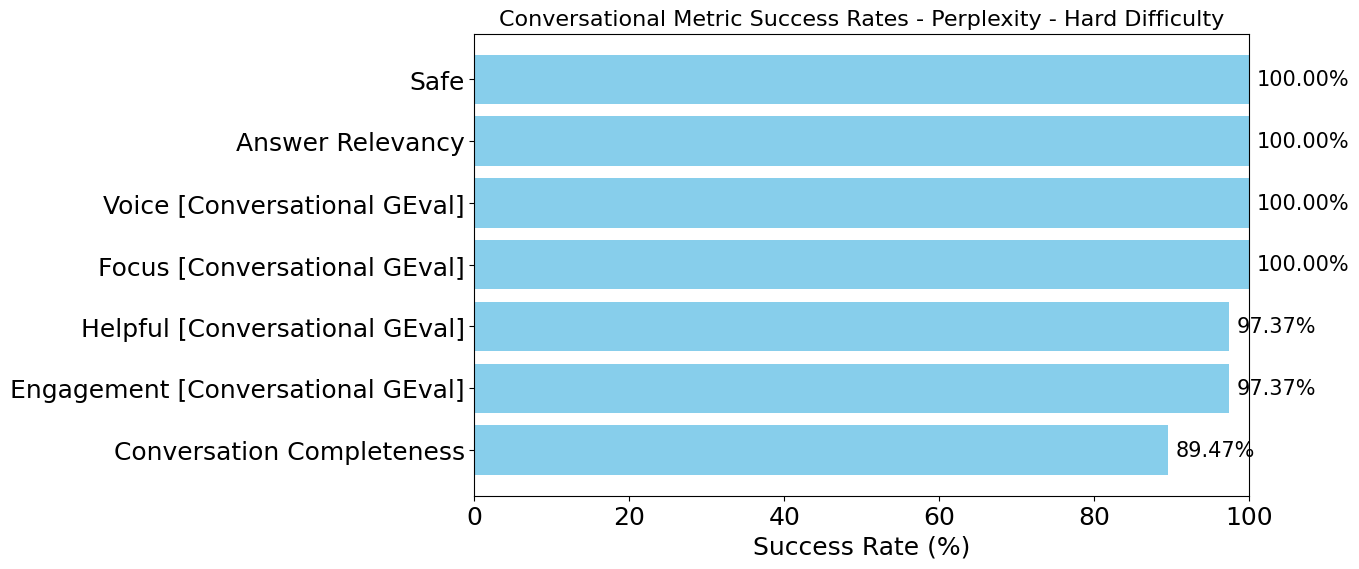

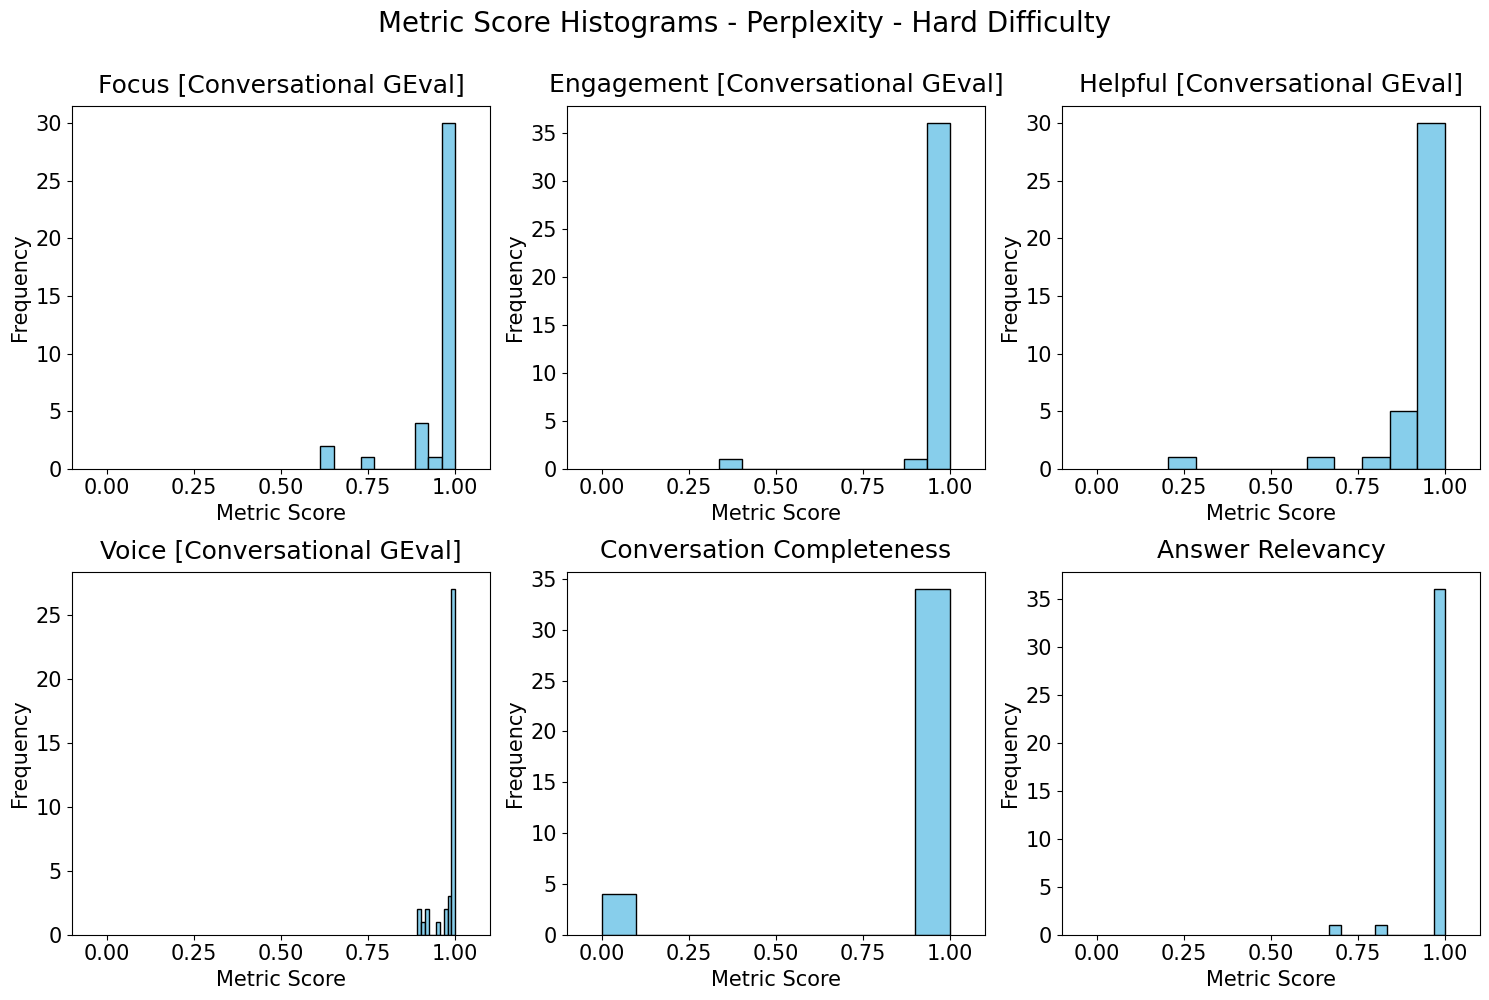

In [5]:

convo_success_rates = calculate_success_rates(data_all_hard)  
metrics, rates = plot_success_rates( convo_success_rates, difficulty_level="Hard", experiment="Perplexity", path="eval_reports"   )  
plot_metric_score_histograms(data_all_hard, difficulty_level="Hard", experiment="Perplexity", path="eval_reports")

data_hard = pd.DataFrame({
    "Metric": metrics,
    "Success Rate": rates
})
data_hard["difficulty_level"] = "Hard"

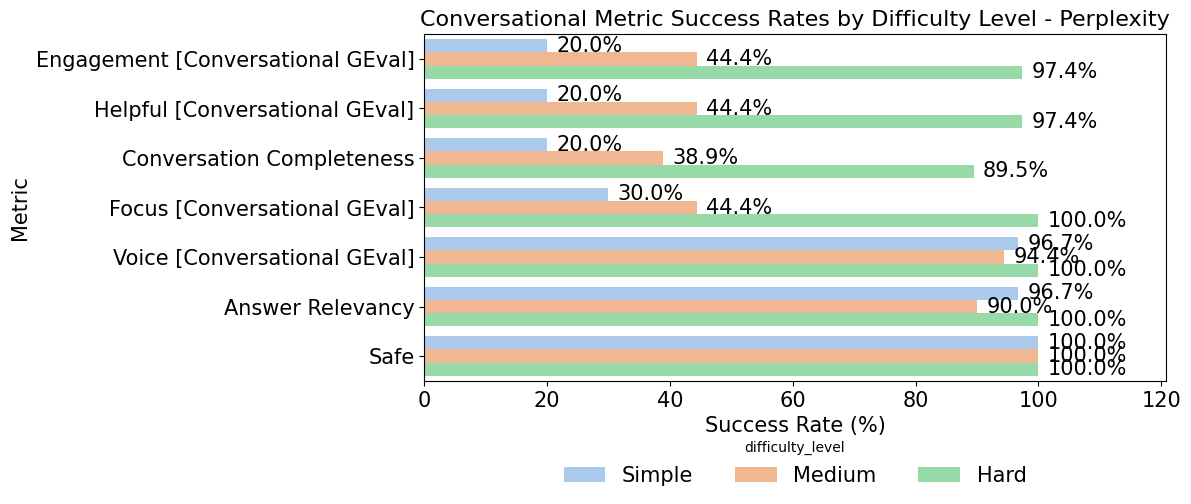

In [6]:
# join data_simple and data_medium
data_all = pd.concat([data_simple, data_medium, data_hard], ignore_index=True) 
data_all["Success Rate"] = data_all["Success Rate"] * 100

plot_all_difficulty_success_rates(data_all, experiment="Perplexity", path="eval_reports")

In [7]:
# data_convo = pd.read_csv("out_ppl/ppl_medium/evaluation_results.csv")
data_rel = data_all_medium[data_all_medium["metric_name"]=="Answer Relevancy"]
data_rel.head()

,name,input,actual_output,expected_output,test_success,metric_name,metric_score,metric_threshold,metric_success,metric_reason,turns
0,test_case_0,What are typical deposit balance ranges by geo...,Typical deposit balances vary widely by region...,NaN,True,Answer Relevancy,1.0,0.5,True,Great job! The answer is fully relevant and di...,NaN
2,test_case_1,Which US regions have the highest concentratio...,Regions with higher incomes and higher costs o...,NaN,True,Answer Relevancy,1.0,0.5,True,The score is 1.00 because the answer was fully...,NaN
4,test_case_2,What are typical deposit balances by customer ...,"Typical deposit balances increase with income,...",NaN,True,Answer Relevancy,1.0,0.5,True,The score is 1.00 because the answer was fully...,NaN
6,test_case_3,What percentage of bank customers maintain acc...,Insufficient information to answer the question.,NaN,True,Answer Relevancy,1.0,0.5,True,The score is 1.00 because the answer was fully...,NaN
8,test_case_4,What are typical inactive account rates by geo...,Insufficient information to answer the question.,NaN,False,Answer Relevancy,0.0,0.5,False,The score is 0.00 because the response did not...,NaN


In [8]:
# data_convo = pd.read_csv("out_ppl/ppl_medium/evaluation_results.csv")
data_rel = data_all_hard[data_all_hard["metric_name"]=="Conversation Completeness"]
data_rel.head()

,name,input,actual_output,expected_output,test_success,metric_name,metric_score,metric_threshold,metric_success,metric_reason,turns
80,conversational_test_case_0,NaN,NaN,NaN,True,Conversation Completeness,1.0,0.5,True,The score is 1.0 because the LLM response full...,"[TurnApi(role='user', content='What are typica..."
85,conversational_test_case_1,NaN,NaN,NaN,True,Conversation Completeness,1.0,0.5,True,The score is 1.0 because the LLM response full...,"[TurnApi(role='user', content='What is the rel..."
90,conversational_test_case_0,NaN,NaN,NaN,True,Conversation Completeness,1.0,0.5,True,The score is 1.0 because the LLM response full...,"[TurnApi(role='user', content='What borrower c..."
95,conversational_test_case_1,NaN,NaN,NaN,True,Conversation Completeness,1.0,0.5,True,The score is 1.0 because the LLM response full...,"[TurnApi(role='user', content='What are early ..."
100,conversational_test_case_0,NaN,NaN,NaN,True,Conversation Completeness,1.0,0.5,True,The score is 1.0 because the LLM response full...,"[TurnApi(role='user', content='Do loan delinqu..."


In [9]:
data_rel.shape, data_rel[data_rel["metric_success"]==False].shape

((38, 11), (4, 11))

In [10]:
for idx, row in data_rel[data_rel["metric_success"]==False].iterrows():
    print(f"Q: {row['input']}")
    print(f"A: {row['actual_output']}")
    print (f"turn: {row['turns']}")
    print(f"Metric Score: {row['metric_score']}")
    print (f"Feedback: {row['metric_reason']}")
    print("-----")

Q: nan
A: nan
turn: [TurnApi(role='user', content='What are industry trends for dormant bank account rates?', order=0, user_id=None, retrieval_context=['user persona: Member Analytics Lead; Compliance Officer', 'KPI: Dormant Account Rate; Inactivity Ratio'], tools_called=None, additional_metadata=None, comments=None), TurnApi(role='assistant', content='Industry commentary indicates that dormant accounts represent a meaningful minority of total accounts at many banks. Over time, digital banking has reduced some dormancy by making access easier, but a long tail of low-balance, rarely used accounts persists. Dormant accounts can accumulate across legacy product sets, closed branches, or customers who have shifted primary relationships elsewhere. Institutions increasingly view dormancy as an operational and risk issue, prompting targeted cleanup and reactivation efforts.', order=1, user_id=None, retrieval_context=None, tools_called=None, additional_metadata=None, comments=None)]
Metric Sco